In [1]:
#cell0
# install pytorch-forecasting and pytorch-lightning
!pip install pytorch-forecasting pytorch-lightning

# clear output 
from IPython.display import clear_output
clear_output()
print("libraries installed!")

libraries installed!


In [2]:
#cell1
import os
import gc
import warnings
import pandas as pd
import numpy as np
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, EncoderNormalizer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.metrics import QuantileLoss

warnings.filterwarnings("ignore")

# check gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# reproducibility
pl.seed_everything(42, workers=True)

Seed set to 42


Device: cuda


42

In [3]:
#cell2
import numpy as np

# define mem optimizer
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage: {start_mem:.2f} MB')
    
    for col in df.columns:
        col_type = df[col].dtype
        
        # skip object, category, datetime
        if col_type != object and col_type.name != 'category' and 'datetime' not in col_type.name:
            c_min = df[col].min()
            c_max = df[col].max()
            
            # downcast integers
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            
            # downcast floats (restricted to float32 minimum for DL stability)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
                    
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Optimized memory: {end_mem:.2f} MB')
    return df

In [4]:
#cell3
import os
import pandas as pd

raw_path = '/kaggle/input/datasets/pgnjams/ie212-favorita-engineered-features-27-stores/kaggle/working/engineered_features_encoded_27_stores.parquet' 
# rename checkpoint to force recreating data with new features
checkpoint_path = '/kaggle/working/optimized_data_checkpoint_v3.parquet'

is_raw_loaded = False

# load data routing
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint: {checkpoint_path}")
    df = pd.read_parquet(checkpoint_path)
    print(f"Checkpoint loaded! Shape: {df.shape}")
else:
    print(f"Loading raw data from: {raw_path}")
    if not os.path.exists(raw_path):
        raise FileNotFoundError(f"Path invalid: {raw_path}. Please check again!")
        
    # load raw and cast date
    df = pd.read_parquet(raw_path)
    df['date'] = pd.to_datetime(df['date'])
    is_raw_loaded = True
    print(f"Raw data loaded! Shape: {df.shape}")

Loading raw data from: /kaggle/input/datasets/pgnjams/ie212-favorita-engineered-features-27-stores/kaggle/working/engineered_features_encoded_27_stores.parquet
Raw data loaded! Shape: (18819628, 32)


In [5]:
#cell4
import pandas as pd
import numpy as np

if is_raw_loaded:
    print("Extracting time features")
    # extract time features from date
    df['day_of_week'] = df['date'].dt.dayofweek.astype(np.int8)
    df['day_of_month'] = df['date'].dt.day.astype(np.int8)
    df['month'] = df['date'].dt.month.astype(np.int8)
    
    # note: if you have a separate file for dcoilwtico (oil price), 
    # it should be merged here before saving the checkpoint.

# print columns to verify
print("Updated columns for modeling:")
print(df.columns.tolist())

Extracting time features
Updated columns for modeling:
['date', 'item_nbr', 'store_nbr', 'id', 'unit_sales', 'onpromotion', 'perishable', 'dcoilwtico', 'kalman_sales', 'wavelet_soft_sales', 'wavelet_hard_sales', 'time_idx', 'lag_1_unit_sales', 'lag_7_unit_sales', 'lag_16_unit_sales', 'lag_1_kalman_sales', 'lag_7_kalman_sales', 'lag_16_kalman_sales', 'lag_1_wavelet_soft_sales', 'lag_7_wavelet_soft_sales', 'lag_16_wavelet_soft_sales', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'city_idx', 'state_idx', 'type_idx', 'cluster_idx', 'family_idx', 'class_idx', 'holiday_type_idx', 'locale_idx', 'day_of_week', 'day_of_month', 'month']


In [6]:
#cell5
import numpy as np

# process and optimize only if raw data is loaded
if is_raw_loaded:
    print("Casting categoricals to int32...")
    # identify categorical columns
    cat_cols = [c for c in df.columns if '_idx' in c] + ['store_nbr', 'item_nbr', 'perishable']
    
    # cast to int32 to prevent int64 RAM spike
    for c in cat_cols:
        df[c] = df[c].astype(np.int32)

    # optimize RAM & save
    print("Running memory optimization...")
    df = reduce_mem_usage(df)
    df.to_parquet(checkpoint_path, index=False)
    print(f"Checkpoint saved to {checkpoint_path}")
else:
    print("Checkpoint was loaded. Skipping processing and saving.")

Casting categoricals to int32...
Running memory optimization...
Memory usage: 2943.44 MB
Optimized memory: 1866.57 MB
Checkpoint saved to /kaggle/working/optimized_data_checkpoint_v3.parquet


In [7]:
# cell 6
import gc
import pandas as pd

# features - Đã thêm dcoilwtico
keep_cols = [
    'date', 'time_idx', 'store_nbr', 'item_nbr', 'city_idx', 'state_idx', 
    'type_idx', 'cluster_idx', 'family_idx', 'class_idx', 'holiday_type_idx', 
    'locale_idx', 'onpromotion', 'perishable', 'unit_sales',
    'day_of_week', 'day_of_month', 'month', 'dcoilwtico'
]

df = df[keep_cols]
context_length = 30 


train_df = df[df['date'] < '2017-07-16'].copy()

val_start = pd.to_datetime('2017-07-16') - pd.Timedelta(days=context_length)
val_df = df[(df['date'] >= val_start) & (df['date'] <= '2017-07-31')].copy()

test_start = pd.to_datetime('2017-08-01') - pd.Timedelta(days=context_length)
test_df = df[(df['date'] >= test_start) & (df['date'] <= '2017-08-15')].copy()

# free ram immediately
del df
gc.collect()

cat_cols = [
    "store_nbr", "item_nbr", "city_idx", "state_idx", 
    "type_idx", "cluster_idx", "family_idx", "class_idx", 
    "holiday_type_idx", "locale_idx", "perishable",
    "day_of_week", "day_of_month", "month" 
]

print("casting to string then category as required by pytorch-forecasting...")
for dataset in [train_df, val_df, test_df]:
    for col in cat_cols:
        # must convert to string first to fix validation error
        dataset[col] = dataset[col].astype(str).astype('category')
    gc.collect() # aggressive clean up to prevent memory spikes

print(f"train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")

casting to string then category as required by pytorch-forecasting...
train: 17265253 | val: 2325291 | test: 2268674


In [8]:
#cell7
from pytorch_forecasting import TimeSeriesDataSet, EncoderNormalizer
from pytorch_forecasting.data.encoders import NaNLabelEncoder

# split categoricals based on their nature
static_cats = [
    "store_nbr", "item_nbr", "city_idx", "state_idx", 
    "type_idx", "cluster_idx", "family_idx", "class_idx", 
    "locale_idx", "perishable"
]
time_cats = ["holiday_type_idx", "day_of_week", "day_of_month", "month"]
all_cats = static_cats + time_cats

# define training set with proper variable mapping and 30-day context
training = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target="unit_sales",
    group_ids=["store_nbr", "item_nbr"],
    min_encoder_length=15,
    max_encoder_length=30,
    max_prediction_length=16,
    static_categoricals=static_cats,
    time_varying_known_categoricals=time_cats,
    time_varying_known_reals=["time_idx", "onpromotion","dcoilwtico"],
    time_varying_unknown_reals=["unit_sales"],
    categorical_encoders={c: NaNLabelEncoder(add_nan=True) for c in all_cats},
    target_normalizer=EncoderNormalizer(transformation="log1p"), 
    add_relative_time_idx=True,
    add_target_scales=True,
    allow_missing_timesteps=True
)

validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=True, stop_randomization=True)

# create dataloaders with lower batch size to prevent OOM
train_dataloader = training.to_dataloader(train=True, batch_size=64, num_workers=2, batch_sampler="synchronized")
val_dataloader = validation.to_dataloader(train=False, batch_size=128, num_workers=2, batch_sampler="synchronized")

print("DataLoaders ready with extended context and corrected features!")

DataLoaders ready with extended context and corrected features!


In [9]:
#cell8
import torch
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

# enable cuDNN for optimization
torch.backends.cudnn.enabled = True 

# build scaled TFT model
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.01, # lowered for smoother convergence
    hidden_size=64, # increased capacity for big data
    attention_head_size=4, # multi-head expansion
    dropout=0.2, # increased to prevent overfitting
    hidden_continuous_size=32, # scaled with hidden_size
    output_size=7, # quantiles
    loss=QuantileLoss(),
    optimizer="adam",
    reduce_on_plateau_patience=4 # dynamic lr decay
)

# ensure gradient flow
for param in tft.parameters():
    param.requires_grad = True

print(f"Number of parameters: {tft.size()/1e3:.1f}k")

Number of parameters: 570.3k


In [10]:
#cell9
import torch
import logging
import warnings
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

# suppress warnings for clean logs
warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

# setup callbacks
early_stop = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=3, verbose=False, mode="min")
checkpoint = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", dirpath="/kaggle/working/", filename="best_tft")

# configure trainer for actual training
trainer = pl.Trainer(
    max_epochs=15, # increased for full convergence
    accelerator="auto",
    devices=1, 
    precision="32-true", # kept 32-bit to prevent NaN in QuantileLoss
    gradient_clip_val=0.5, # relaxed to allow faster learning
    limit_train_batches=3000, # increased data coverage per epoch
    limit_val_batches=800,
    num_sanity_val_steps=0, 
    inference_mode=False,
    enable_progress_bar=False,  
    callbacks=[early_stop, checkpoint]
)

# train
print("Starting TFT training loop...")
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
print("Training completed!")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Starting TFT training loop...


2026-06-01 13:22:44.511225: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780320164.739325      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780320164.805207      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780320165.347312      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780320165.347338      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780320165.347341      23 computation_placer.cc:177] computation placer alr

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  270 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    512 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 26.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 37.0 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 29.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 570 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 570 K                                                                                                
Total estimated model params size (MB): 2.281                                                                      
Modules in train mode: 422                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training completed!


In [11]:
# cell 10
import gc
import numpy as np
import pandas as pd
import torch
from pytorch_forecasting.models import TemporalFusionTransformer

print("loading model to gpu...")
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path).to('cuda')

print("predicting on val set...")

predict_results = best_tft.predict(
    val_dataloader, 
    mode="prediction", 
    return_index=True, 
    trainer_kwargs=dict(accelerator="gpu")
)
val_preds = predict_results[0].cpu().numpy()
val_index = next(item for item in predict_results if isinstance(item, pd.DataFrame))

# unroll - optimize mem
n_samples = len(val_index)
store_reps = np.repeat(val_index['store_nbr'].values, 16)
item_reps = np.repeat(val_index['item_nbr'].values, 16)
time_reps = np.repeat(val_index['time_idx'].values, 16) + np.tile(np.arange(0, 16), n_samples)


# do NOT cast to str, keep as category/int to save RAM
df_val_preds = pd.DataFrame({
    'store_nbr': store_reps, 
    'item_nbr': item_reps,
    'time_idx': time_reps.astype(np.int32),
    'predicted_sales': np.round(np.clip(val_preds.flatten(), 0, None), 4).astype(np.float32)
})

# free mem immediately
del val_preds, store_reps, item_reps, time_reps
gc.collect()

# merge real
val_meta = val_df[['store_nbr', 'item_nbr', 'time_idx', 'unit_sales', 'perishable']].drop_duplicates()
# ensure merge keys match types, avoid str
val_meta['time_idx'] = val_meta['time_idx'].astype(np.int32)

df_val_final = df_val_preds.merge(val_meta, on=['store_nbr', 'item_nbr', 'time_idx'], how='inner')

# free intermediate dfs
del df_val_preds, val_meta
gc.collect()

# metrics
actuals = np.clip(df_val_final['unit_sales'].values, 0, None)
preds = df_val_final['predicted_sales'].values
weights = 1.0 + 0.25 * df_val_final['perishable'].astype(np.float32).values

def nwrmsle(y_true, y_pred, w):
    log_err = (np.log1p(y_pred) - np.log1p(y_true))**2
    return np.sqrt(np.sum(w * log_err) / np.sum(w))

final_nwrmsle = nwrmsle(actuals, preds, weights)
final_wmae = np.sum(weights * np.abs(actuals - preds)) / np.sum(weights)
final_wrmse = np.sqrt(np.sum(weights * (actuals - preds)**2) / np.sum(weights))

print(f"nwrmsle: {final_nwrmsle:.4f} | wrmse: {final_wrmse:.4f} | wmae: {final_wmae:.4f}")

torch.save(best_tft.state_dict(), 'best_tft_weights.pth')
print("exported best_tft_weights.pth")

loading model to gpu...


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


predicting on val set...
nwrmsle: 0.5183 | wrmse: 13.6111 | wmae: 3.2141
exported best_tft_weights.pth


In [12]:
# cell 11
import gc
import pandas as pd
import numpy as np
from pytorch_forecasting import TimeSeriesDataSet

print("generating predictions on test set...")
test_dataset = TimeSeriesDataSet.from_dataset(training, test_df, predict=True, stop_randomization=True)
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=128, num_workers=2)


test_results = best_tft.predict(
    test_dataloader, 
    mode="prediction", 
    return_index=True, 
    trainer_kwargs=dict(accelerator="gpu")
)
test_preds = test_results[0]
test_index = next(item for item in test_results if isinstance(item, pd.DataFrame))

y_pred_test = np.clip(test_preds.cpu().numpy(), 0, None)

# unroll
n_samples = len(test_index)
store_reps = np.repeat(test_index['store_nbr'].values, 16)
item_reps = np.repeat(test_index['item_nbr'].values, 16)
time_reps = np.repeat(test_index['time_idx'].values, 16) + np.tile(np.arange(0, 16), n_samples)


# avoid str, use float32
df_preds = pd.DataFrame({
    'store_nbr': store_reps,
    'item_nbr': item_reps,
    'time_idx': time_reps.astype(np.int32),
    'predicted_sales': np.round(y_pred_test.flatten(), 4).astype(np.float32)
})

# free mem
del test_preds, store_reps, item_reps, time_reps
gc.collect()

# merge test meta
test_meta = test_df[['store_nbr', 'item_nbr', 'time_idx', 'date', 'unit_sales']].drop_duplicates()
test_meta['time_idx'] = test_meta['time_idx'].astype(np.int32)

df_preds = df_preds.merge(test_meta, on=['store_nbr', 'item_nbr', 'time_idx'], how='left')

# free mem
del test_meta
gc.collect()

df_preds.rename(columns={'unit_sales': 'actual_sales'}, inplace=True)
df_preds = df_preds.dropna(subset=['date'])
df_preds['date'] = pd.to_datetime(df_preds['date']).dt.strftime('%Y-%m-%d')

# export
req_cols = ['date', 'store_nbr', 'item_nbr', 'actual_sales', 'predicted_sales']
df_preds[req_cols].to_csv('preds_track3.csv', index=False)
print("exported preds_track3.csv")

generating predictions on test set...


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


exported preds_track3.csv


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Extracting raw predictions for interpretation 
Calculating and plotting feature importance...
Saved: tft_importance_attention.png
Saved: tft_importance_static_variables.png
Saved: tft_importance_encoder_variables.png
Saved: tft_importance_decoder_variables.png


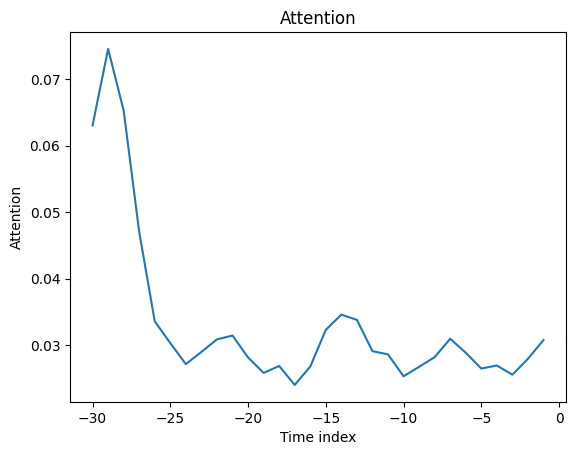

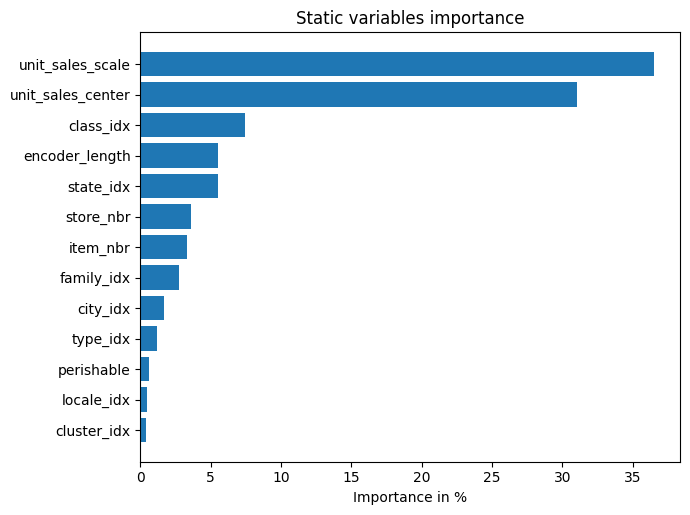

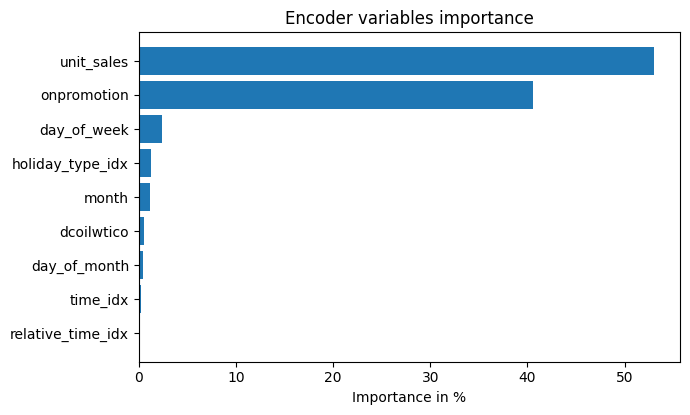

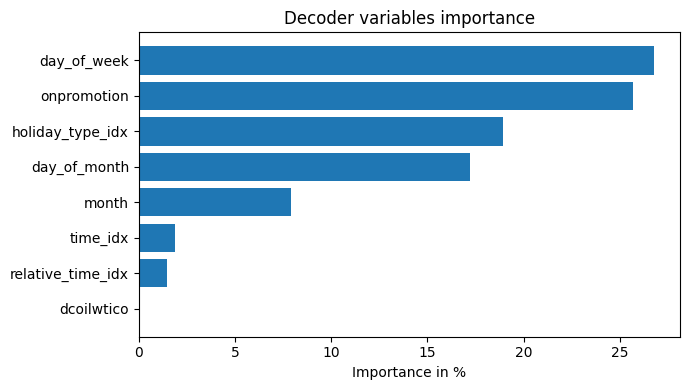

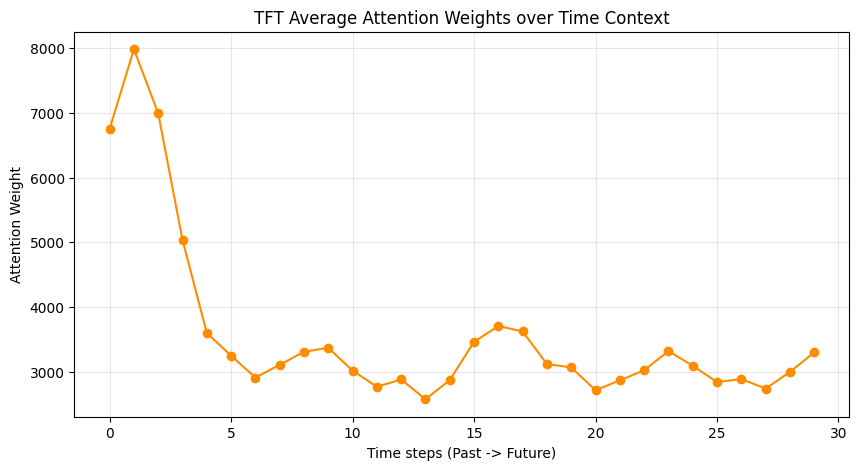

Generating forecast plot with confidence bounds...


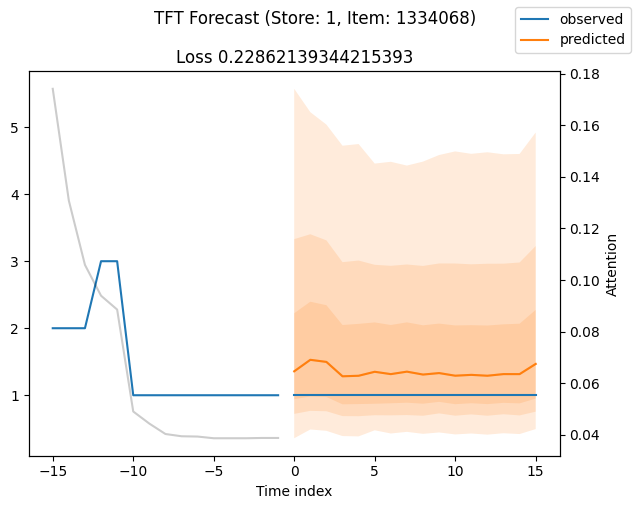

All visual assets exported successfully!


In [13]:
#cell12
import matplotlib.pyplot as plt

print("Extracting raw predictions for interpretation ")
# Get raw predictions and input features (x) for interpretation
predict_raw_res = best_tft.predict(
    val_dataloader, 
    mode="raw", 
    return_x=True,
    trainer_kwargs=dict(accelerator="gpu")
)


raw_preds = predict_raw_res[0]
x = predict_raw_res[1]

print("Calculating and plotting feature importance...")
interpretation = best_tft.interpret_output(raw_preds, reduction="sum")

# 1. Plot and save Feature Importances safely
figs = best_tft.plot_interpretation(interpretation)
for name, fig in figs.items():
    fig.savefig(f'tft_importance_{name}.png', bbox_inches='tight', dpi=300)
    print(f"Saved: tft_importance_{name}.png")

# 2. Plot Attention Weights over time
plt.figure(figsize=(10, 5))
attention_mean = interpretation["attention"].cpu().numpy()
plt.plot(attention_mean, marker='o', color='darkorange')
plt.title("TFT Average Attention Weights over Time Context")
plt.xlabel("Time steps (Past -> Future)")
plt.ylabel("Attention Weight")
plt.grid(True, alpha=0.3)
plt.savefig('tft_attention_weights.png', bbox_inches='tight', dpi=300)
plt.show()

# 3. Plot Actual vs Predicted with Quantile Bounds
print("Generating forecast plot with confidence bounds...")
sample_idx = 0 
fig_pred = best_tft.plot_prediction(x, raw_preds, idx=sample_idx, add_loss_to_title=True)
store_nbr = val_index.iloc[sample_idx]["store_nbr"]
item_nbr = val_index.iloc[sample_idx]["item_nbr"]

# ĐÃ FIX: Thêm y=1.05 để đẩy tiêu đề lên cao, tránh bị đè chữ
fig_pred.suptitle(f'TFT Forecast (Store: {store_nbr}, Item: {item_nbr})', fontsize=12, y=1.05)

# Lưu ảnh với bbox_inches='tight' để không bị cắt xén tiêu đề
fig_pred.savefig('tft_forecast_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

print("All visual assets exported successfully!")

In [14]:
# cell13
import json
import pandas as pd

print("exporting data for cross-track analysis")

# export metrics
tft_metrics = {
    "NWRMSLE": float(final_nwrmsle),
    "WRMSE": float(final_wrmse),
    "WMAE": float(final_wmae)
}
with open('tft_metrics.json', 'w') as f:
    json.dump(tft_metrics, f, indent=4)
print("saved: tft_metrics.json")

# extract sample for 3-way comparison
sample_track = df_preds[(df_preds['store_nbr'] == '3') & (df_preds['item_nbr'] == '1503844')].copy()

if not sample_track.empty:
    # sync columns with kalman/wavelet
    export_df = sample_track[['date', 'actual_sales', 'predicted_sales']].copy()
    export_df.rename(columns={'actual_sales': 'unit_sales', 'predicted_sales': 'tft_sales'}, inplace=True)
    export_df.to_csv('tft_sample_for_comparison.csv', index=False)
    print("saved: tft_sample_for_comparison.csv")
else:
    print("warning: sample not found in test predictions")

# export feature importance
encoder_imp = pd.DataFrame({
    'feature': best_tft.encoder_variables,
    'importance': interpretation['encoder_variables'].cpu().numpy()
})
decoder_imp = pd.DataFrame({
    'feature': best_tft.decoder_variables,
    'importance': interpretation['decoder_variables'].cpu().numpy()
})
static_imp = pd.DataFrame({
    'feature': best_tft.static_variables,
    'importance': interpretation['static_variables'].cpu().numpy()
})

# combine importances
all_imp = pd.concat([encoder_imp, decoder_imp, static_imp]).groupby('feature').sum().reset_index()
all_imp = all_imp.sort_values(by='importance', ascending=False)
all_imp.to_csv('tft_feature_importance.csv', index=False)
print("saved: tft_feature_importance.csv")

exporting data for cross-track analysis
saved: tft_metrics.json
saved: tft_sample_for_comparison.csv
saved: tft_feature_importance.csv


Generating Evaluation Plots...


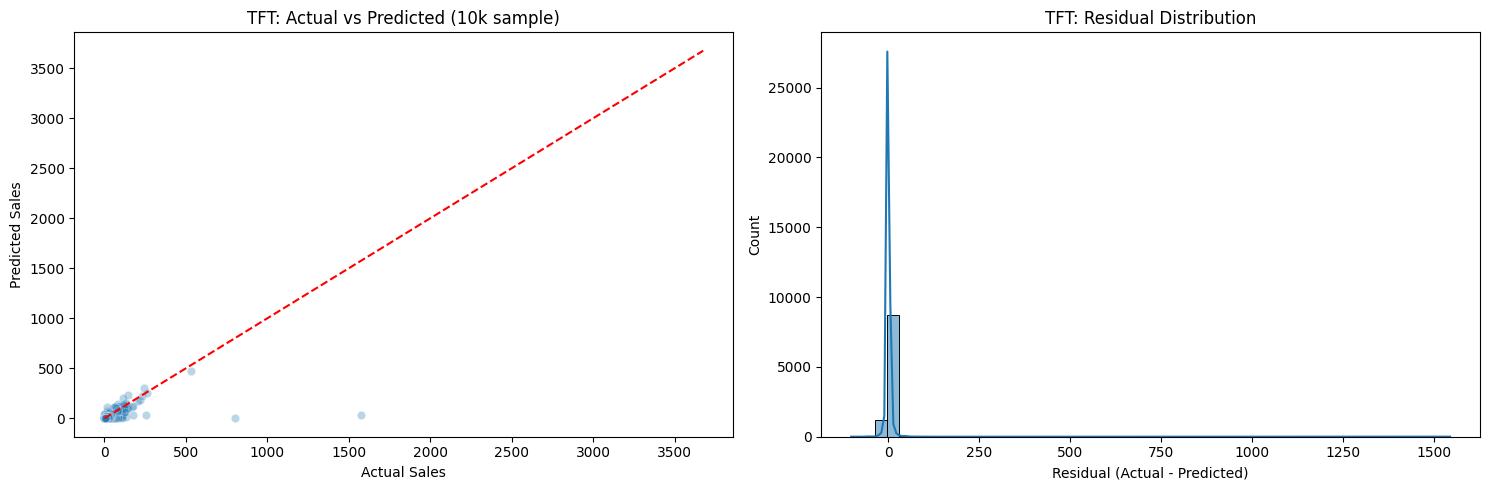

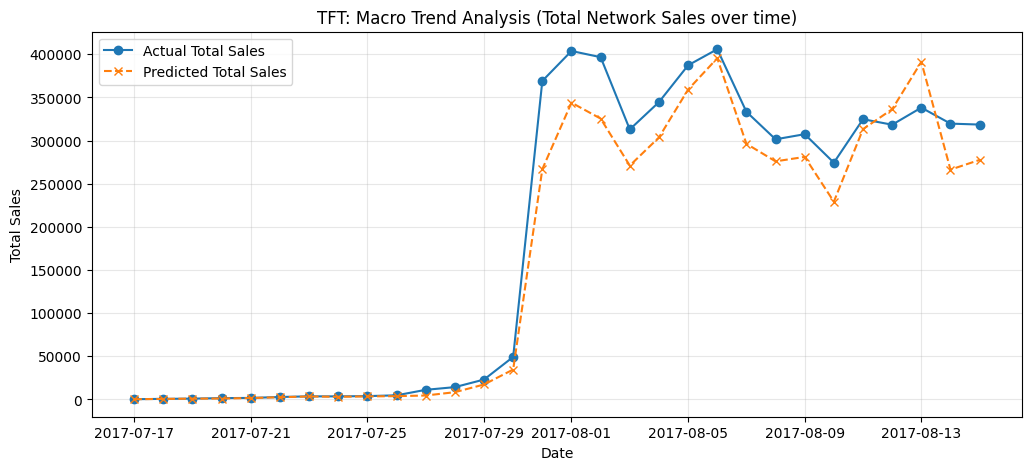

In [15]:
#cell14
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Evaluation Plots...")

# Calculate residuals
df_preds['residual'] = df_preds['actual_sales'] - df_preds['predicted_sales']

# 1. Residual Analysis Plot (Scatter + Histogram)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: Actual vs Predicted
sns.scatterplot(x='actual_sales', y='predicted_sales', data=df_preds.sample(n=10000, random_state=42), alpha=0.3, ax=ax[0])
ax[0].plot([0, df_preds['actual_sales'].max()], [0, df_preds['actual_sales'].max()], color='red', linestyle='--')
ax[0].set_title('TFT: Actual vs Predicted (10k sample)')
ax[0].set_xlabel('Actual Sales')
ax[0].set_ylabel('Predicted Sales')

# Histogram of Residuals
sns.histplot(df_preds['residual'].sample(n=10000, random_state=42), bins=50, kde=True, ax=ax[1])
ax[1].set_title('TFT: Residual Distribution')
ax[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.savefig('tft_residual_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

# 2. Macro Trend Plot (Total Daily Sales)
macro_trend = df_preds.groupby('date')[['actual_sales', 'predicted_sales']].sum().reset_index()
macro_trend['date'] = pd.to_datetime(macro_trend['date'])

plt.figure(figsize=(12, 5))
plt.plot(macro_trend['date'], macro_trend['actual_sales'], label='Actual Total Sales', marker='o')
plt.plot(macro_trend['date'], macro_trend['predicted_sales'], label='Predicted Total Sales', marker='x', linestyle='--')
plt.title('TFT: Macro Trend Analysis (Total Network Sales over time)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('tft_actual_vs_predicted_trend.png', bbox_inches='tight', dpi=300)
plt.show()

In [16]:
# cell 15 
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

print("Extracting Training History")

# Tìm ở working trước , nếu không có thì tìm ở input 
log_dirs = glob.glob('/kaggle/working/lightning_logs/version_*/metrics.csv')
if not log_dirs:
    log_dirs = glob.glob('/kaggle/input/**/metrics.csv', recursive=True)

if log_dirs:
    # Lấy file log mới nhất
    latest_log = max(log_dirs, key=os.path.getctime) if 'working' in log_dirs[0] else log_dirs[0]
    print(f"Đã tìm thấy file log tại: {latest_log}")
    
    # Read metrics
    metrics_df = pd.read_csv(latest_log)
    
    # Extract train and val loss, forward fill to align epochs
    loss_history = metrics_df[['epoch', 'train_loss_step', 'val_loss']].groupby('epoch').mean().reset_index()
    
    # Save to CSV for cross-track comparison
    loss_history.to_csv('tft_loss_history.csv', index=False)
    print("Saved: tft_loss_history.csv")
    
    # Plot Loss Curve
    plt.figure(figsize=(10, 5))
    if 'train_loss_step' in loss_history.columns:
        plt.plot(loss_history['epoch'], loss_history['train_loss_step'], label='Train Loss', marker='o')
    if 'val_loss' in loss_history.columns:
        plt.plot(loss_history['epoch'], loss_history['val_loss'], label='Val Loss', marker='s')
        
    plt.title('TFT Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (QuantileLoss)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('tft_loss_curve.png', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("No lightning logs found in both working and input directories.")

Extracting Training History
No lightning logs found in both working and input directories.


extracting tft sample for store: 3, item: 1503844...


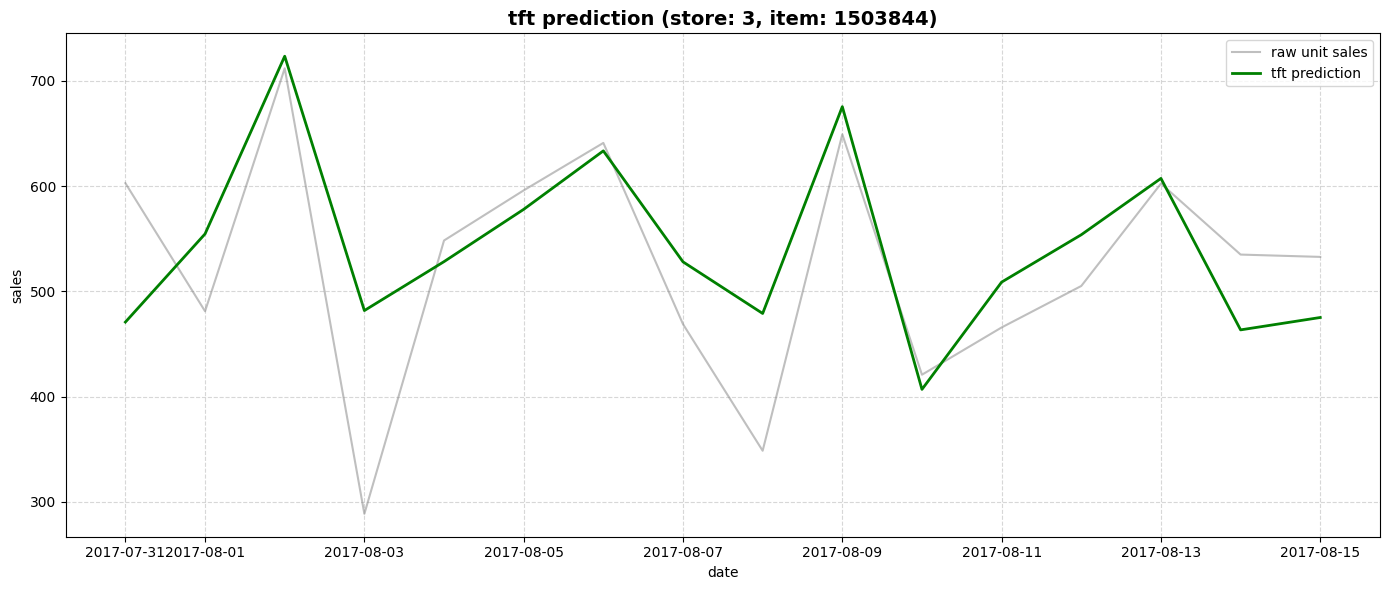

saved: tft_sample_effect.png


In [17]:
# cell 16: plot tft prediction for cross-track comparison
import pandas as pd
import matplotlib.pyplot as plt
import os

# fixed sample to match with kalman and wavelet
SAMPLE_STORE = 3 
SAMPLE_ITEM = 1503844

print(f"extracting tft sample for store: {SAMPLE_STORE}, item: {SAMPLE_ITEM}...")

tft_preds_file = 'preds_track3.csv' 

if not os.path.exists(tft_preds_file):
    print(f"error: {tft_preds_file} not found. please check your prediction output filename.")
else:
    df_tft = pd.read_csv(tft_preds_file)
    
    sample_df = df_tft[(df_tft['store_nbr'] == SAMPLE_STORE) & (df_tft['item_nbr'] == SAMPLE_ITEM)].copy()
    
    if sample_df.empty:
        print("error: sample not found in dataset.")
    else:
        sample_df['date'] = pd.to_datetime(sample_df['date'])
        sample_df = sample_df.sort_values('date')

        # plot
        plt.figure(figsize=(14, 6))
        plt.plot(sample_df['date'], sample_df['actual_sales'], label='raw unit sales', alpha=0.5, color='gray')
        plt.plot(sample_df['date'], sample_df['predicted_sales'], label='tft prediction', linewidth=2, color='green')

        plt.title(f'tft prediction (store: {SAMPLE_STORE}, item: {SAMPLE_ITEM})', fontsize=14, fontweight='bold')
        plt.xlabel('date')
        plt.ylabel('sales')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()

        plt.savefig('tft_sample_effect.png', dpi=300)
        plt.show()

        print("saved: tft_sample_effect.png")